# **Import Libraries**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AI learning/AI Engineering /Module 3 - Machine Learning/Assignment/Online_Retail.csv',encoding='latin1')

# **Dataset Overview**

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 5268


In [9]:
df.nunique()


,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [10]:
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/11 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/11 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/11 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/11 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/11 8:40,9.95,13502.0,United Kingdom


# **Data Cleaning**

**Remove null values**

In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


**Remove duplicate rows**

In [13]:
df = df.drop_duplicates()
print("Duplicated rows",df.duplicated().sum())


Duplicated rows 0


In [14]:
print(df.shape)


(401604, 8)


**Convert CustomerID to Integer**

In [15]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  int64  
 7   Country      401604 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 27.6+ MB


**Remove Cancelled Transactions**

In [17]:
# Number of cancelled transactions
cancelled_orders = df["InvoiceNo"].astype(str).str.startswith("C").sum()

print(f"Cancelled Transactions: {cancelled_orders}")
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

Cancelled Transactions: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548,United Kingdom


In [18]:
#Remove cancelled transactions:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Dataset Shape:", df.shape)

Dataset Shape: (392732, 8)


**Remove Invalid Quantity**

In [19]:
#View invalid quantities
print("Invalid Quantities:", (df["Quantity"] <= 0).sum())

Invalid Quantities: 0


**Remove Invalid Unit Prices**

In [20]:
#Check invalid prices
print("Invalid Unit Prices:", (df["UnitPrice"] <= 0).sum())

Invalid Unit Prices: 40


In [21]:
#View invalid records
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/10 14:02,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,12/16/10 14:36,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,12/21/10 13:45,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,1/6/11 16:41,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,1/6/11 16:41,0.0,13081,United Kingdom


In [22]:
#Remove invalid prices
df = df[df["UnitPrice"] > 0]

print("Dataset Shape:", df.shape)

Dataset Shape: (392692, 8)


**Final Data cleaning summary**

In [23]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nCancelled Transactions:",
      df["InvoiceNo"].astype(str).str.startswith("C").sum())

print("\nInvalid Quantities:",
      (df["Quantity"] <= 0).sum())

print("\nInvalid Unit Prices:",
      (df["UnitPrice"] <= 0).sum())

Final Dataset Shape: (392692, 8)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate Rows: 0

Cancelled Transactions: 0

Invalid Quantities: 0

Invalid Unit Prices: 0


# **Feature Engineering (RFM Analysis)**
### What is RFM Analysis?

**RFM** is a customer segmentation technique used to analyze customer purchasing behavior based on three key metrics:

- **Recency (R):** How recently a customer made their last purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much money a customer has spent.

These three features will be used as the input for the **K-Means Clustering** algorithm to group customers with similar purchasing behavior.

**Convert InvoiceDate to Datetime**

In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

**Create Total Amount**

In [25]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34




### Calculate Reference Date

To calculate **Recency**, we need a **reference date**.  
We use **one day after the latest transaction date** in the dataset as the reference date.

This allows us to calculate the number of days since each customer's last purchase.

**Example:**

- Latest transaction date: **2011-12-09**
- Reference date: **2011-12-10**

A customer whose last purchase was on **2011-12-09** will have a **Recency = 1 day**.

In [26]:
# Calculate reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


# **Create RFM Table**
The RFM table is created by grouping the dataset based on **CustomerID**.

For each customer, we calculate:

- **Recency:** Number of days since the customer's last purchase.
- **Frequency:** Total number of unique transactions made by the customer.
- **Monetary:** Total amount spent by the customer.

These RFM features will be used as input for the clustering algorithm.

**Create the RFM DataFrame**

In [27]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

**Rename Columns**

In [28]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
#Display table
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [29]:
#check shape
print(rfm.shape)

(4338, 3)


In [30]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


# **Exploratory Data Analysis (EDA) on RFM Features**

Before applying K-Means clustering, it is important to understand the distribution of the RFM features.

In this section, we will:

- Analyze the distribution of **Recency**, **Frequency**, and **Monetary**.
- Detect potential outliers using boxplots.
- Understand customer purchasing behavior before clustering.

**Distribution of RFM Features**

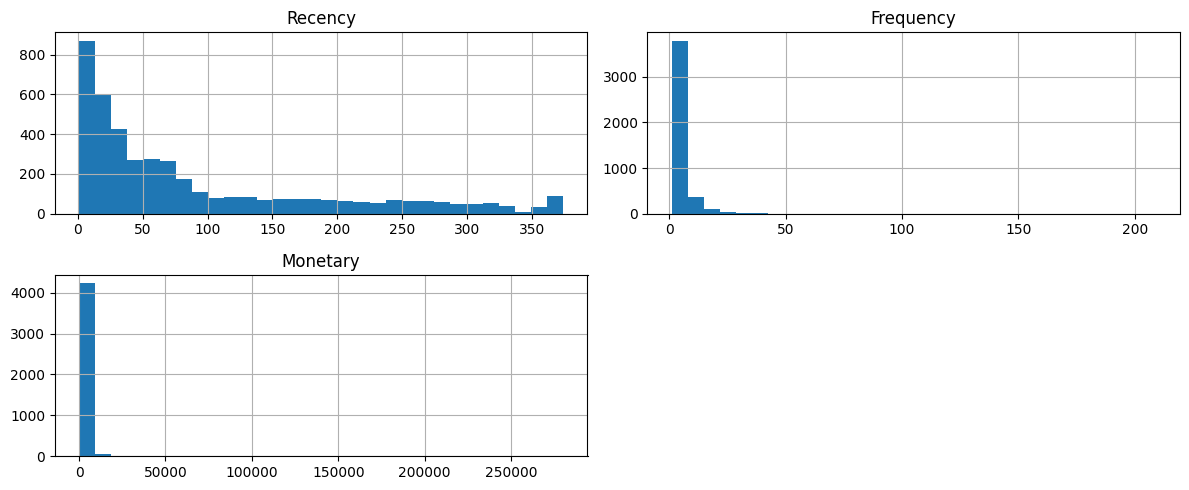

In [31]:
rfm.hist(figsize=(12,5), bins=30)

plt.tight_layout()
plt.show()

**Boxplots**

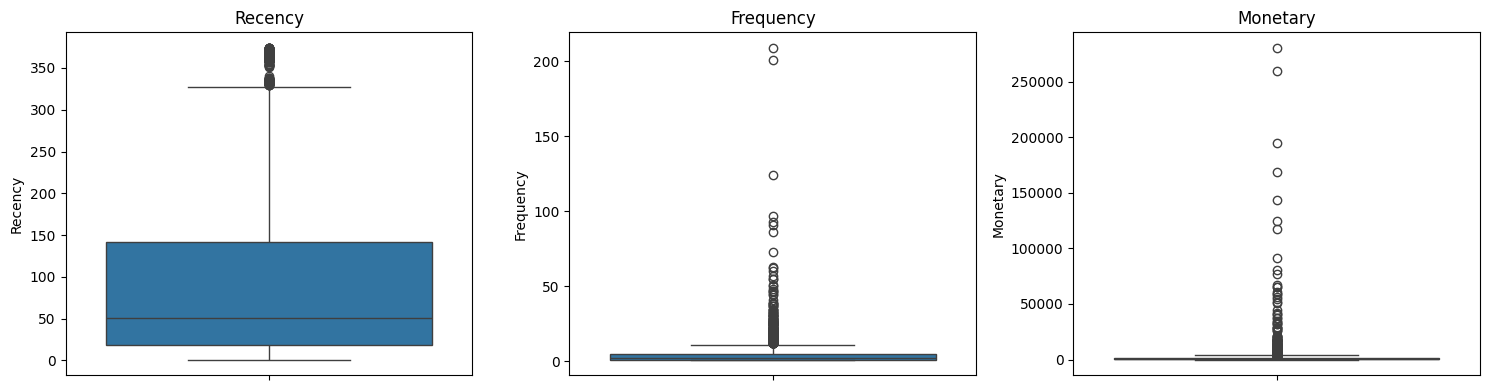

In [32]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(y=rfm["Recency"])
plt.title("Recency")

plt.subplot(1,3,2)
sns.boxplot(y=rfm["Frequency"])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.boxplot(y=rfm["Monetary"])
plt.title("Monetary")

plt.tight_layout()
plt.show()

**Correlation Matrix**

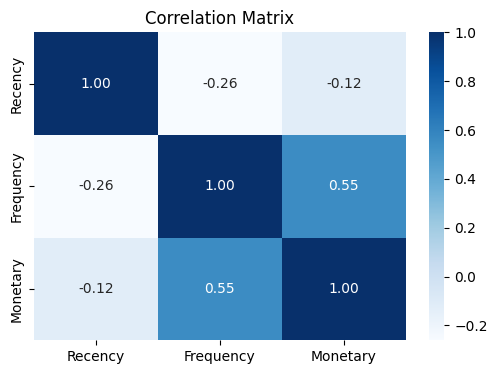

In [33]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Observations

- **Recency** is positively skewed. Most customers have made recent purchases, while a small number of customers have not purchased for a long time.
- **Frequency** is highly right-skewed. Most customers have made only a few purchases, while a few customers have purchased very frequently.
- **Monetary** is also highly right-skewed. Most customers spend relatively small amounts, whereas a small number of customers contribute significantly higher revenue.
- Boxplots indicate the presence of several outliers in all three RFM features.
- These outliers represent genuine high-value customers and will be retained for clustering instead of being removed.
- The correlation matrix shows a moderate positive correlation (**0.55**) between **Frequency** and **Monetary**, indicating that customers who purchase more frequently tend to spend more.
- **Recency** has a weak negative correlation with both **Frequency** and **Monetary**, suggesting that recently active customers generally purchase more often and spend more.

# **Feature Scaling**

K-Means clustering is a distance-based algorithm. Since the RFM features have different scales, feature scaling is required to ensure that each feature contributes equally during clustering.

We will use **StandardScaler** to standardize the features before training the K-Means model.

**Scale the Features**

In [34]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

**Convert Back to DataFrame**

In [35]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

**Check the Scaled Data**

In [36]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.363010
12347,-0.905340,0.354417,0.251699
12348,-0.175360,-0.035340,-0.027988
12349,-0.735345,-0.425097,-0.032406
12350,2.174578,-0.425097,-0.190812


**Verify Scaling**

In [37]:
rfm_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,2.702618e-17,1.000115,-0.915340,-0.745345,-0.415353,0.494623,2.814561
Frequency,4338.0,1.801745e-17,1.000115,-0.425097,-0.425097,-0.295178,0.094579,26.598031
Monetary,4338.0,2.293130e-17,1.000115,-0.227615,-0.193919,-0.153616,-0.043197,30.960742


# **Choosing the Optimal Number of Clusters**

K-Means requires the number of clusters (**K**) to be specified before training the model.

To determine the optimal value of **K**, we will use two evaluation techniques:

- **Elbow Method** – Measures the Within-Cluster Sum of Squares (WCSS) for different values of K.
- **Silhouette Score** – Measures how well-separated and cohesive the clusters are.

The optimal number of clusters will be selected based on the combined results of both methods.

**Elbow Method**

In [38]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

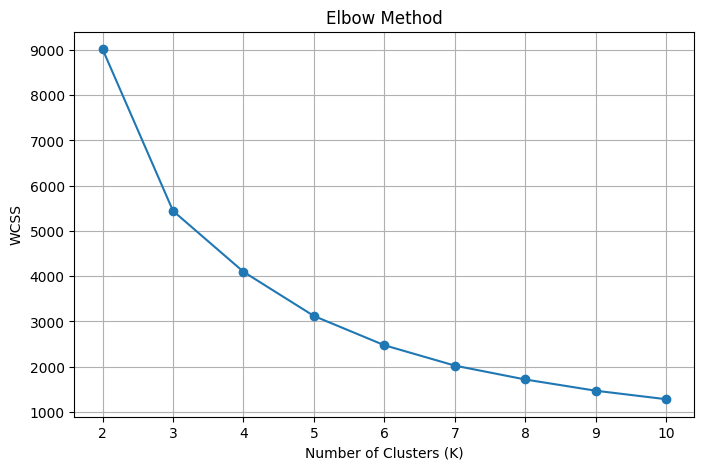

In [40]:
#Plot the Elbow curve:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

**Silhouette Score**

In [42]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

#print silhouette_scores
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

K = 2: 0.8958
K = 3: 0.5942
K = 4: 0.6162
K = 5: 0.6165
K = 6: 0.5983
K = 7: 0.5165
K = 8: 0.4859
K = 9: 0.4784
K = 10: 0.4792


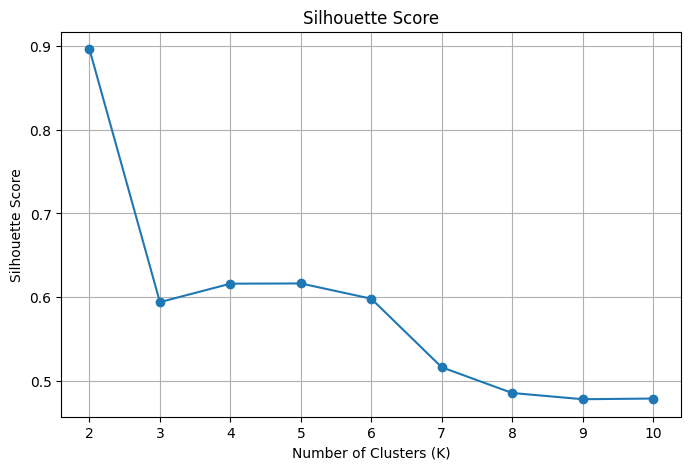

In [43]:
#Plot silhouette_scores
plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker="o")

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

### Final Selection of K

Although the highest Silhouette Score was obtained for **K = 2**, this would produce only two broad customer groups, which provides limited business value.

The **Elbow Method** indicates a clear elbow around **K = 5**, and the Silhouette Score for **K = 5 (0.6165)** remains relatively high.

Therefore, considering both clustering performance and business interpretability, the final number of clusters was selected as **K = 5**.

# **Model Building (K-Means Clustering)**

In [44]:
#Set the Optimal Number of Clusters
optimal_k = 5

**Train the K-Means Model**

In [45]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(rfm_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [47]:
#Assign cluster labels
rfm["Cluster"] = kmeans.labels_
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


In [49]:
#Check Cluster Distribution
rfm["Cluster"].value_counts().sort_index()

,count
Cluster,
0,3048
1,1063
2,8
3,213
4,6


**Visualize Cluster Distribution**

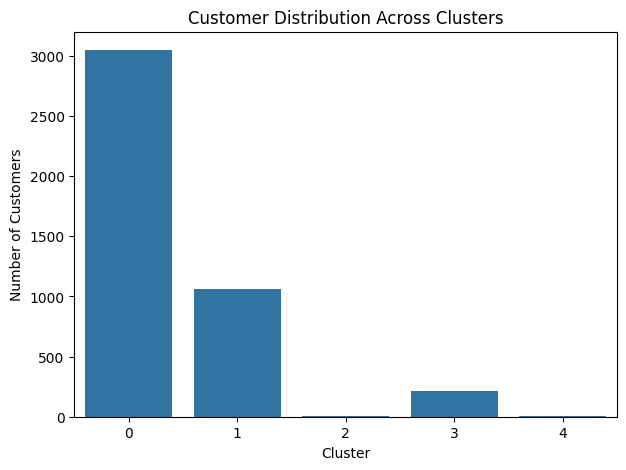

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(data=rfm, x="Cluster")

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# **Cluster Analysis**

After training the K-Means model, we analyze each cluster by calculating the average **Recency**, **Frequency**, and **Monetary** values.

This helps us understand the purchasing behavior of customers in each cluster and assign meaningful business labels to each segment.

**Cluster Summary**

In [51]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.92,3.65,1333.13
1,248.47,1.55,478.65
2,6.50,120.50,55099.49
3,15.67,21.29,12813.94
4,7.67,42.83,190808.54


**Number of Customers in Each Cluster**

In [52]:
cluster_size = rfm["Cluster"].value_counts().sort_index()

cluster_size

,count
Cluster,
0,3048
1,1063
2,8
3,213
4,6


**Add Customer Count to Summary**

In [53]:
cluster_summary["CustomerCount"] = cluster_size

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.92,3.65,1333.13,3048
1,248.47,1.55,478.65,1063
2,6.50,120.50,55099.49,8
3,15.67,21.29,12813.94,213
4,7.67,42.83,190808.54,6


| Cluster | Interpretation             | Reason                                                                                                   |
| ------- | -------------------------- | -------------------------------------------------------------------------------------------------------- |
| **0**   | 🛍️ **Regular Customers**  | Medium recency, low frequency, medium spending. Largest customer group.                                  |
| **1**   | ⚠️ **At-Risk Customers**   | Highest recency (248 days), very low frequency and low spending. They haven't purchased for a long time. |
| **2**   | 💎 **Loyal Customers**     | Very recent, extremely high purchase frequency, very high spending.                                      |
| **3**   | ⭐ **High-Value Customers** | Recent customers with high frequency and high spending.                                                  |
| **4**   | 👑 **VIP Customers**       | Most valuable customers with exceptionally high spending and frequent purchases (only 6 customers).      |


**Visualize Cluster Characteristics**

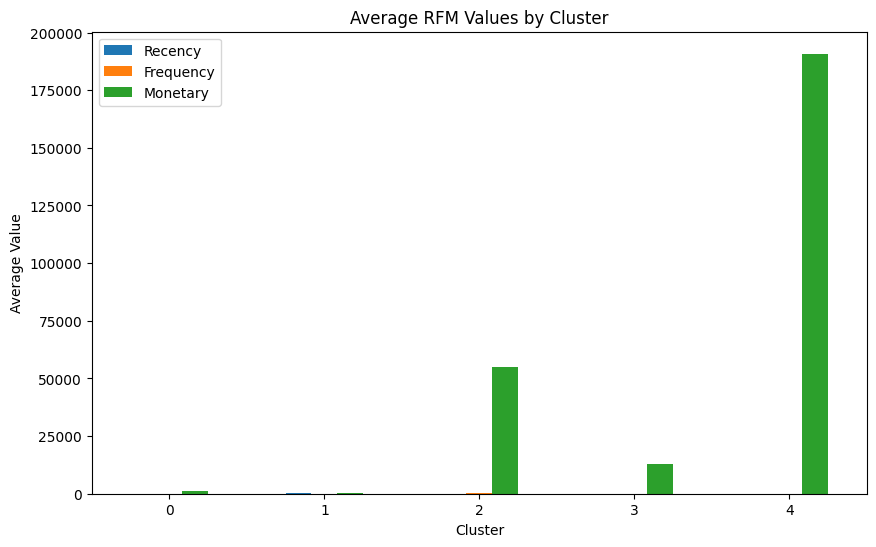

In [54]:
cluster_summary[["Recency", "Frequency", "Monetary"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average RFM Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

# **Business Insights**

Based on the average RFM values, the customer segments can be interpreted as follows:

- **Cluster 0 – Regular Customers**
  - Largest customer group.
  - Moderate purchasing activity and spending.
  - Opportunity for upselling and personalized recommendations.

- **Cluster 1 – At-Risk Customers**
  - Customers have not purchased for a long time.
  - Low purchase frequency and low spending.
  - Suitable for win-back campaigns and special discounts.

- **Cluster 2 – Loyal Customers**
  - Highly active customers with very frequent purchases.
  - Generate significant revenue.
  - Ideal candidates for loyalty programs and exclusive offers.

- **Cluster 3 – High-Value Customers**
  - Frequently purchase and spend large amounts.
  - Important customers who should receive personalized services and premium support.

- **Cluster 4 – VIP Customers**
  - The smallest but most valuable customer segment.
  - Extremely high spending and frequent purchases.
  - Should receive VIP treatment, premium memberships, and exclusive rewards.

# **Cluster Visualization**
PCA (Principal Component Analysis)

In [55]:
#Apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

rfm_pca = pca.fit_transform(rfm_scaled)

In [58]:
#Create PCA Dataframe
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

**Scatter plot**

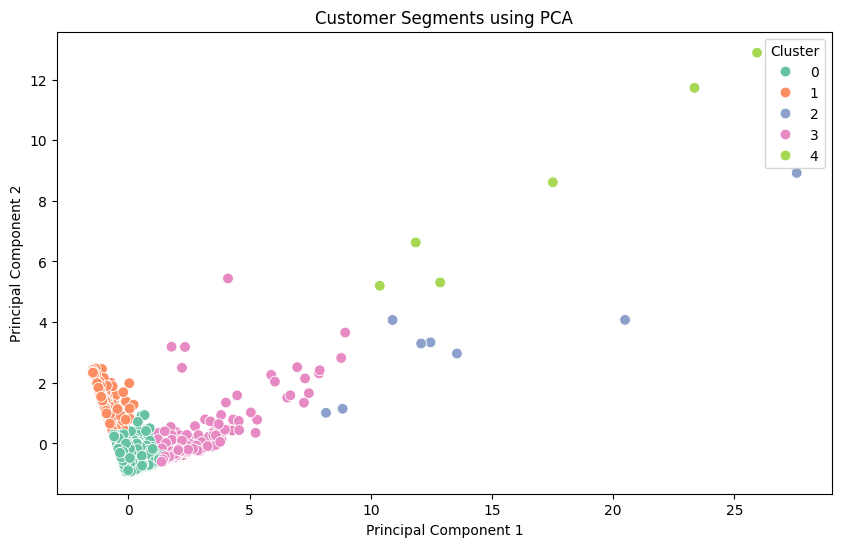

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

# **Save the model**

In [61]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


# **Conclusion**

### Conclusion

In this project, we developed an end-to-end customer segmentation pipeline using **RFM Analysis** and **K-Means Clustering**.

The workflow included:

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Data cleaning
- RFM feature engineering
- Feature scaling using StandardScaler
- Optimal cluster selection using the Elbow Method and Silhouette Score
- Customer segmentation using K-Means Clustering
- Cluster visualization using PCA
- Business interpretation of customer segments
- Saving the trained model and scaler for deployment

The resulting customer segments can help businesses design targeted marketing campaigns, improve customer retention, and identify high-value customers.